In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [2]:
df = pd.read_csv("../data/km_classifier_dummy_dataset.csv")

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (200, 16)

Column Names:
 ['ride_id', 'requestedAt', 'status', 'driver_availability', 'demand_level', 'fare_INR', 'rideKm', 'durationMin', 'pickup_lat', 'pickup_lng', 'drop_lat', 'drop_lng', 'peak_hour_flag', 'demand_supply_ratio', 'surge_multiplier', 'label']

First 5 rows:


,ride_id,requestedAt,status,driver_availability,demand_level,fare_INR,rideKm,durationMin,pickup_lat,pickup_lng,drop_lat,drop_lng,peak_hour_flag,demand_supply_ratio,surge_multiplier,label
0,RIDE0001,2024-06-12 03:01:47,completed,1,medium,201.63,28.73,85.1,18.601653,73.783408,18.488373,73.941300,0,1.38,1.00,0
1,RIDE0002,2024-03-11 07:14:08,cancelled,0,low,280.59,7.37,28.4,18.454917,73.783524,18.514674,73.897502,1,1.87,1.29,0
2,RIDE0003,2024-01-27 21:47:57,completed,0,high,207.45,23.69,110.9,18.454425,73.757334,18.495331,73.820650,1,2.86,1.73,1
3,RIDE0004,2024-05-19 02:37:27,completed,1,low,143.87,24.86,107.7,18.514722,73.897280,18.520999,73.809307,0,0.54,1.00,0
4,RIDE0005,2024-01-09 00:05:13,completed,1,medium,166.86,17.83,80.5,18.547729,73.882761,18.463885,73.819941,0,1.17,1.00,0


In [3]:
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 ride_id                0
requestedAt            0
status                 0
driver_availability    0
demand_level           0
fare_INR               0
rideKm                 0
durationMin            0
pickup_lat             0
pickup_lng             0
drop_lat               0
drop_lng               0
peak_hour_flag         0
demand_supply_ratio    0
surge_multiplier       0
label                  0
dtype: int64

Data Types:
 ride_id                 object
requestedAt             object
status                  object
driver_availability      int64
demand_level            object
fare_INR               float64
rideKm                 float64
durationMin            float64
pickup_lat             float64
pickup_lng             float64
drop_lat               float64
drop_lng               float64
peak_hour_flag           int64
demand_supply_ratio    float64
surge_multiplier       float64
label                    int64
dtype: object

Duplicate Rows: 0


Label Distribution:
label
0    137
1     63
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_6976\1548110346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Blues')


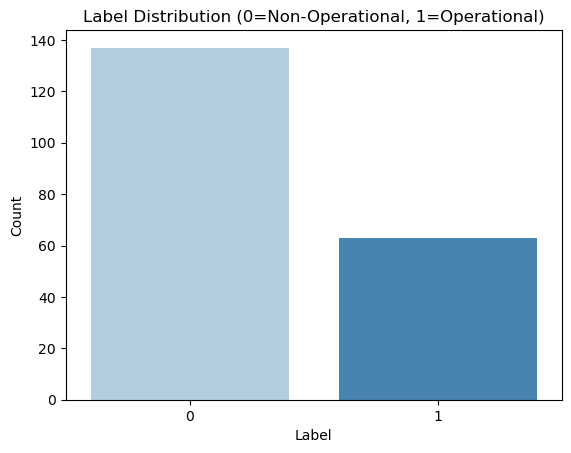

In [4]:
print("Label Distribution:")
print(df['label'].value_counts())

# Plot it
sns.countplot(x='label', data=df, palette='Blues')
plt.title('Label Distribution (0=Non-Operational, 1=Operational)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6976\4192912855.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='demand_level', data=df, palette='Set2')


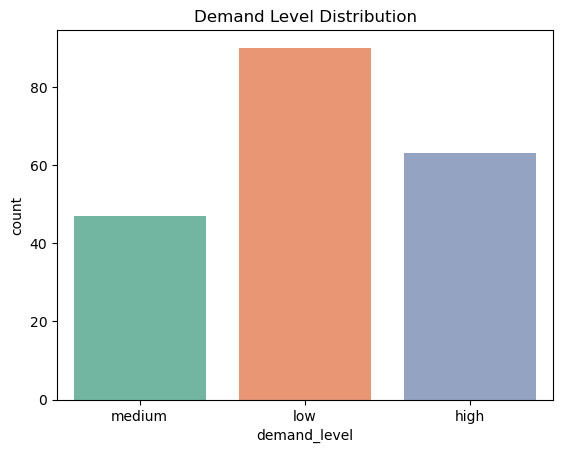

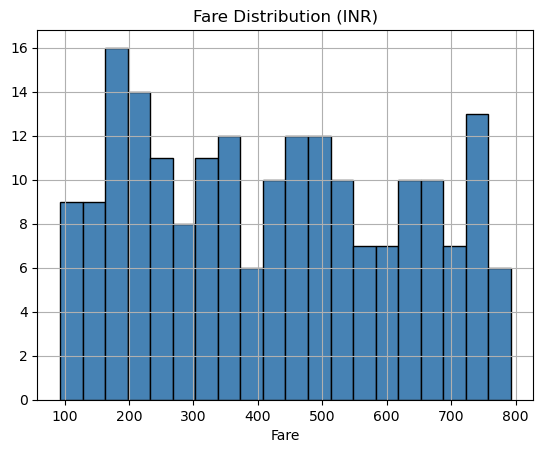

C:\Users\Admin\AppData\Local\Temp\ipykernel_6976\4192912855.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='peak_hour_flag', data=df, palette='Set1')


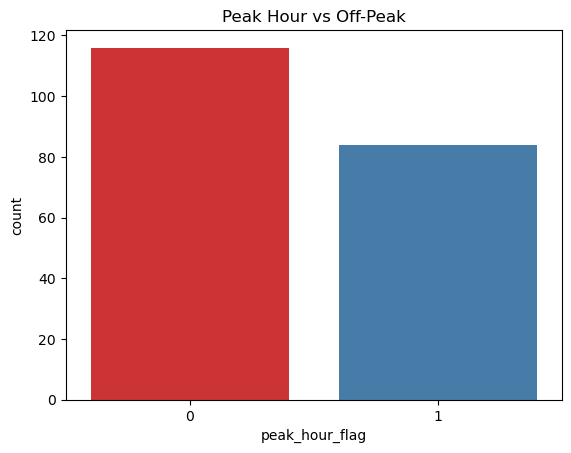

In [5]:
# Demand level distribution
sns.countplot(x='demand_level', data=df, palette='Set2')
plt.title('Demand Level Distribution')
plt.show()

# Fare distribution
df['fare_INR'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Fare Distribution (INR)')
plt.xlabel('Fare')
plt.show()

# Peak hour distribution
sns.countplot(x='peak_hour_flag', data=df, palette='Set1')
plt.title('Peak Hour vs Off-Peak')
plt.show()

In [6]:
df['requestedAt'] = pd.to_datetime(df['requestedAt'])
df['hour']        = df['requestedAt'].dt.hour
df['day_of_week'] = df['requestedAt'].dt.dayofweek
df['month']       = df['requestedAt'].dt.month

df.drop(columns=['requestedAt', 'ride_id'], inplace=True)

print("New shape:", df.shape)
print("New columns:", df.columns.tolist())

New shape: (200, 17)
New columns: ['status', 'driver_availability', 'demand_level', 'fare_INR', 'rideKm', 'durationMin', 'pickup_lat', 'pickup_lng', 'drop_lat', 'drop_lng', 'peak_hour_flag', 'demand_supply_ratio', 'surge_multiplier', 'label', 'hour', 'day_of_week', 'month']


In [7]:
from sklearn.preprocessing import LabelEncoder

le_status = LabelEncoder()
le_demand = LabelEncoder()

df['status']       = le_status.fit_transform(df['status'])
df['demand_level'] = le_demand.fit_transform(df['demand_level'])

print("Status classes:", le_status.classes_)
print("Demand classes:", le_demand.classes_)
df.head()

Status classes: ['cancelled' 'completed']
Demand classes: ['high' 'low' 'medium']


,status,driver_availability,demand_level,fare_INR,rideKm,durationMin,pickup_lat,pickup_lng,drop_lat,drop_lng,peak_hour_flag,demand_supply_ratio,surge_multiplier,label,hour,day_of_week,month
0,1,1,2,201.63,28.73,85.1,18.601653,73.783408,18.488373,73.941300,0,1.38,1.00,0,3,2,6
1,0,0,1,280.59,7.37,28.4,18.454917,73.783524,18.514674,73.897502,1,1.87,1.29,0,7,0,3
2,1,0,0,207.45,23.69,110.9,18.454425,73.757334,18.495331,73.820650,1,2.86,1.73,1,21,5,1
3,1,1,1,143.87,24.86,107.7,18.514722,73.897280,18.520999,73.809307,0,0.54,1.00,0,2,6,5
4,1,1,2,166.86,17.83,80.5,18.547729,73.882761,18.463885,73.819941,0,1.17,1.00,0,0,1,1


In [8]:
X = df.drop(columns=['label'])
y = df['label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:\n", y.value_counts())

Features shape: (200, 16)
Target shape: (200,)

Target distribution:
 label
0    137
1     63
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done ✅")
print("Sample scaled values:\n", X_scaled[:2])

Scaling done ✅
Sample scaled values:
 [[ 0.58504861  0.64686916  1.46481923 -1.11398705  0.85664574  0.23662715
   0.91754203 -1.16314184 -1.0130442   1.58620324 -0.85096294  0.06808365
  -0.73134181 -1.22715801 -0.54425623  1.60538105]
 [-1.70925967 -1.54590766  0.10850513 -0.71969636 -1.0926616  -1.00866333
  -1.61014725 -1.16112434 -0.56548088  0.81076117  1.1751393   0.7741363
  -0.13483183 -0.64314468 -1.5615576  -0.25773042]]


In [10]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE: ", dict(zip(*np.unique(y_resampled, return_counts=True))))

Before SMOTE: {0: 137, 1: 63}
After SMOTE:  {np.int64(0): np.int64(137), np.int64(1): np.int64(137)}


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.30,
    random_state=42,
    stratify=y_resampled
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train distribution:\n", pd.Series(y_train).value_counts())
print("y_test distribution:\n",  pd.Series(y_test).value_counts())

X_train shape: (191, 16)
X_test shape:  (83, 16)
y_train distribution:
 label
1    96
0    95
Name: count, dtype: int64
y_test distribution:
 label
0    42
1    41
Name: count, dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"{name} — trained ✅")

Logistic Regression — trained ✅
Random Forest — trained ✅
XGBoost — trained ✅


In [13]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)

for name, model in trained.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.2%}")
    print(f"  Precision: {precision_score(y_test, y_pred):.2%}")
    print(f"  Recall   : {recall_score(y_test, y_pred):.2%}")
    print(f"  F1 Score : {f1_score(y_test, y_pred):.2%}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_test, y_pred,
          target_names=['Non-Operational', 'Operational']))


  Logistic Regression
  Accuracy : 91.57%
  Precision: 88.64%
  Recall   : 95.12%
  F1 Score : 91.76%

  Classification Report:

                 precision    recall  f1-score   support

Non-Operational       0.95      0.88      0.91        42
    Operational       0.89      0.95      0.92        41

       accuracy                           0.92        83
      macro avg       0.92      0.92      0.92        83
   weighted avg       0.92      0.92      0.92        83


  Random Forest
  Accuracy : 100.00%
  Precision: 100.00%
  Recall   : 100.00%
  F1 Score : 100.00%

  Classification Report:

                 precision    recall  f1-score   support

Non-Operational       1.00      1.00      1.00        42
    Operational       1.00      1.00      1.00        41

       accuracy                           1.00        83
      macro avg       1.00      1.00      1.00        83
   weighted avg       1.00      1.00      1.00        83


  XGBoost
  Accuracy : 96.39%
  Precision: 95.24%
 

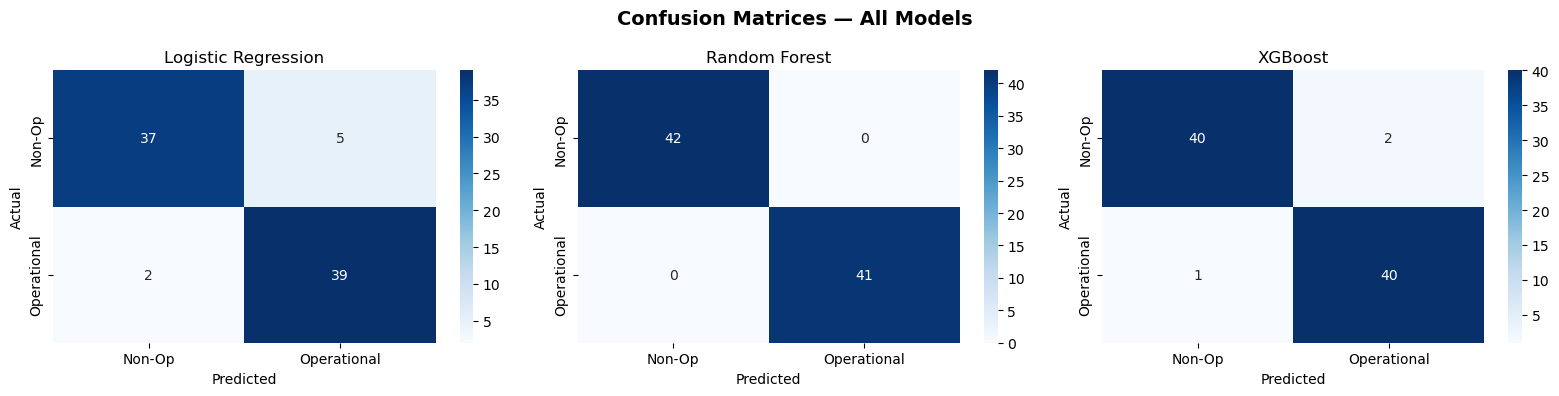

Saved to models/confusion_matrix.png ✅


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, trained.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=['Non-Op', 'Operational'],
                yticklabels=['Non-Op', 'Operational'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png')
plt.show()
print("Saved to models/confusion_matrix.png ✅")

                     Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.915663   0.886364  0.95122  0.917647
Random Forest        1.000000   1.000000  1.00000  1.000000
XGBoost              0.963855   0.952381  0.97561  0.963855


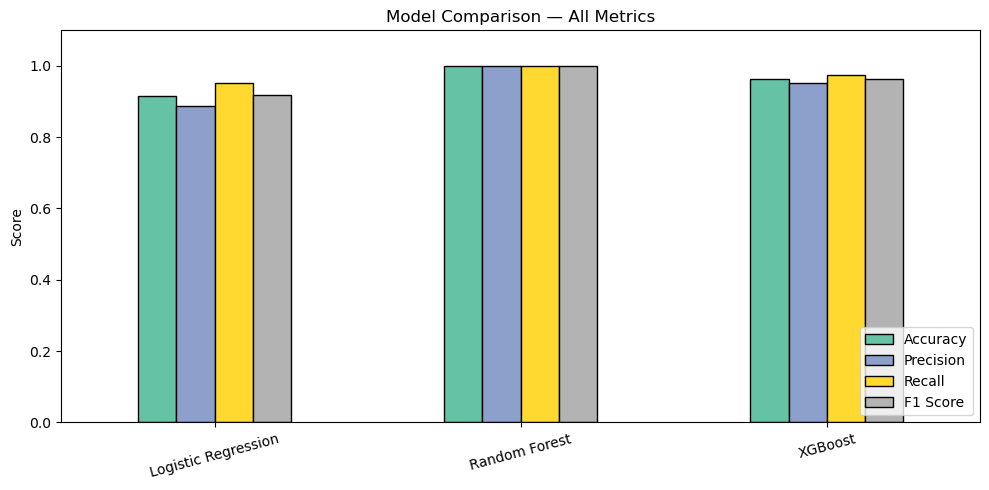

Saved to models/model_comparison.png ✅


In [15]:
results = {}
for name, model in trained.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — All Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../models/model_comparison.png')
plt.show()
print("Saved to models/model_comparison.png ✅")

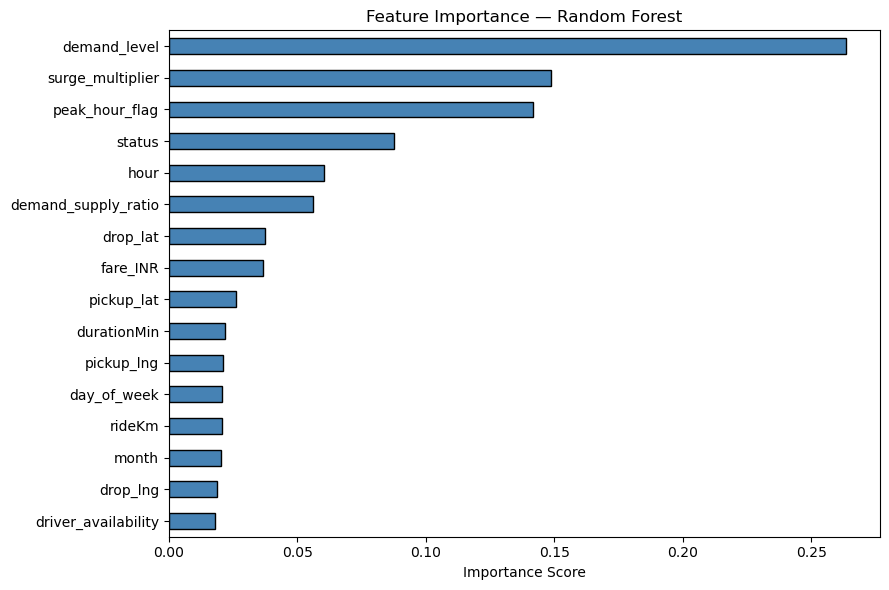

Saved to models/feature_importance.png ✅


In [16]:
feature_names = df.drop(columns=['label']).columns

importances = pd.Series(
    trained["Random Forest"].feature_importances_,
    index=feature_names
).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(9, 6),
                 color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../models/feature_importance.png')
plt.show()
print("Saved to models/feature_importance.png ✅")

In [18]:
import joblib

best_model = trained["XGBoost"]

joblib.dump(best_model, '../models/km_classifier.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')

print("Best model saved  -> models/km_classifier.pkl")
print("Scaler saved      -> models/scaler.pkl")

Best model saved  -> models/km_classifier.pkl
Scaler saved      -> models/scaler.pkl
